# Gamma Diagnostics Analysis

这个 notebook 对应 `02_analyze_gamma_diagnostics.py`，用于交互式查看 `gamma` 扫描结果、生成图像，以及按需导出误差表。

In [27]:
from __future__ import annotations

import csv
import html
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

plt.rcParams["figure.dpi"] = 150

In [28]:
INPUT_PATH = Path("data/imex_gamma_diagnostics_pilot.h5")
FIG_DIR = Path("fig")
TABLE_PATH = Path("data/imex_gamma_diagnostics_table.csv")

SAVE_FIGURES = False
SAVE_TABLE = False

In [35]:
def gamma_label(gamma: float) -> str:
    return f"gamma_{gamma:g}".replace("-", "m").replace(".", "p")


def choose_sample_times(t: np.ndarray) -> np.ndarray:
    tf = float(t[-1])
    if tf >= 10.0:
        return np.array([2.0, 4.0, 6.0, 8.0, 10.0], dtype=np.float64)
    count = min(5, max(1, len(t) - 1))
    return np.linspace(float(t[1]), tf, count)


def nearest_time_index(t: np.ndarray, target: float) -> int:
    return int(np.argmin(np.abs(t - target)))


def load_data(path: Path):
    with h5py.File(path, "r") as f:
        completed_step = int(f.attrs.get("completed_step", len(f["time/t"]) - 1))
        sl = slice(0, completed_step + 1)
        t = f["time/t"][sl]
        gamma_values = tuple(float(x) for x in f.attrs["gamma_values"])
        gamma_data = {
            gamma: {
                "q": f[gamma_label(gamma)]["q"][sl],
                "Enstrophy": f[gamma_label(gamma)]["Enstrophy"][sl],
                "rel_l2_error": f[f"errors/{gamma_label(gamma)}"]["rel_l2_error"][sl],
                "rel_enstrophy_error": f[f"errors/{gamma_label(gamma)}"]["rel_enstrophy_error"][sl],
            }
            for gamma in gamma_values
        }
        ref_enstrophy = f["etdrk4_ref"]["Enstrophy"][sl]
        attrs = dict(f.attrs)
    return t, gamma_values, gamma_data, ref_enstrophy, attrs


def plot_diagnostics(t, gamma_values, gamma_data, ref_enstrophy, attrs):
    colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(gamma_values)))
    fig, axes = plt.subplots(1, 3, figsize=(12.0, 3.6), dpi=180)
    ax_err, ax_q, ax_ens = axes

    for color, gamma in zip(colors, gamma_values):
        data = gamma_data[gamma]
        label = rf"$\gamma={gamma:g}$"
        rel_l2 = np.asarray(data["rel_l2_error"], dtype=np.float64)
        q_dev = np.abs(np.asarray(data["q"], dtype=np.float64) - 1.0)
        ax_err.semilogy(t, np.maximum(rel_l2, 1.0e-16), color=color, lw=1.4, label=label)
        ax_q.semilogy(t, np.maximum(q_dev, 1.0e-16), color=color, lw=1.4, label=label)
        ax_ens.plot(t, data["Enstrophy"], color=color, lw=1.2, label=label)

    ax_ens.plot(t, ref_enstrophy, color="black", lw=1.2, ls="--", label="ETDRK4 ref")
    ax_err.set_xlabel("t")
    ax_err.set_ylabel("relative L2 error")
    ax_err.set_ylim(1.0e-11, 10.0)
    ax_err.set_xlim(0.0, float(t[-1]))
    ax_q.set_xlabel("t")
    ax_q.set_ylabel("|q - 1|")
    ax_q.set_ylim(1.0e-7, 5.0)
    ax_q.set_xlim(0.0, float(t[-1]))
    ax_ens.set_xlabel("t")
    ax_ens.set_ylabel("Enstrophy")
    ax_ens.set_xlim(0.0, float(t[-1]))

    title = (
        f"IMEX-mr-SAV-{attrs.get('method', 'rk?')}, "
        rf"$\delta t ={attrs.get('dt', np.nan):g}$"
    )
    fig.suptitle(title)
    for ax in axes:
        ax.grid(True, which="major", color="0.85", ls="--", lw=0.5)
        ax.tick_params(direction="in", top=True, right=True)

    handles, labels = ax_err.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=min(6, len(labels)), frameon=True)
    fig.subplots_adjust(bottom=0.28, top=0.82, wspace=0.32)
    return fig


def build_error_table_rows(t, gamma_values, gamma_data):
    sample_times = choose_sample_times(t)
    rows = []
    for target in sample_times:
        idx = nearest_time_index(t, target)
        row = {"time": float(t[idx])}
        for gamma in gamma_values:
            data = gamma_data[gamma]
            row[f"gamma_{gamma:g}_rel_l2"] = float(data["rel_l2_error"][idx])
            row[f"gamma_{gamma:g}_rel_enstrophy"] = float(data["rel_enstrophy_error"][idx])
        rows.append(row)
    return rows


def display_table(rows):
    if not rows:
        display(HTML("<p><em>No rows to display.</em></p>"))
        return

    fieldnames = list(rows[0].keys())
    parts = [
        "<table>",
        "<thead><tr>",
        *[f"<th>{html.escape(name)}</th>" for name in fieldnames],
        "</tr></thead>",
        "<tbody>",
    ]
    for row in rows:
        parts.append("<tr>")
        for name in fieldnames:
            value = row[name]
            if isinstance(value, float):
                text = f"{value:.8e}" if "gamma_" in name else f"{value:.12g}"
            else:
                text = str(value)
            parts.append(f"<td>{html.escape(text)}</td>")
        parts.append("</tr>")
    parts.append("</tbody></table>")
    display(HTML("".join(parts)))


def save_figure(fig, fig_dir: Path):
    fig_dir.mkdir(parents=True, exist_ok=True)
    pdf_path = fig_dir / "imex_gamma_diagnostics.pdf"
    png_path = fig_dir / "imex_gamma_diagnostics.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    return pdf_path, png_path


def save_table(rows, table_path: Path):
    table_path.parent.mkdir(parents=True, exist_ok=True)
    fieldnames = list(rows[0].keys()) if rows else ["time"]
    with table_path.open("w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in rows:
            writer.writerow({
                key: (f"{value:.8e}" if isinstance(value, float) and key != "time" else f"{value:.12g}" if key == "time" else value)
                for key, value in row.items()
            })
    return table_path

In [30]:
t, gamma_values, gamma_data, ref_enstrophy, attrs = load_data(INPUT_PATH)

print(f"input: {INPUT_PATH}")
print(f"method: {attrs.get('method', 'unknown')}")
print(f"grid: {tuple(attrs.get('grid', []))}")
print(f"dt: {attrs.get('dt', np.nan)}")
print(f"completed steps: {len(t) - 1}")
print(f"time span: [{float(t[0]):.6g}, {float(t[-1]):.6g}]")
print(f"gamma values: {gamma_values}")

input: data/imex_gamma_diagnostics_pilot.h5
method: rk3
grid: (np.int64(64), np.int64(64))
dt: 0.001
completed steps: 10000
time span: [0, 10]
gamma values: (0.0, 1.0, 10.0, 100.0, 1000.0)


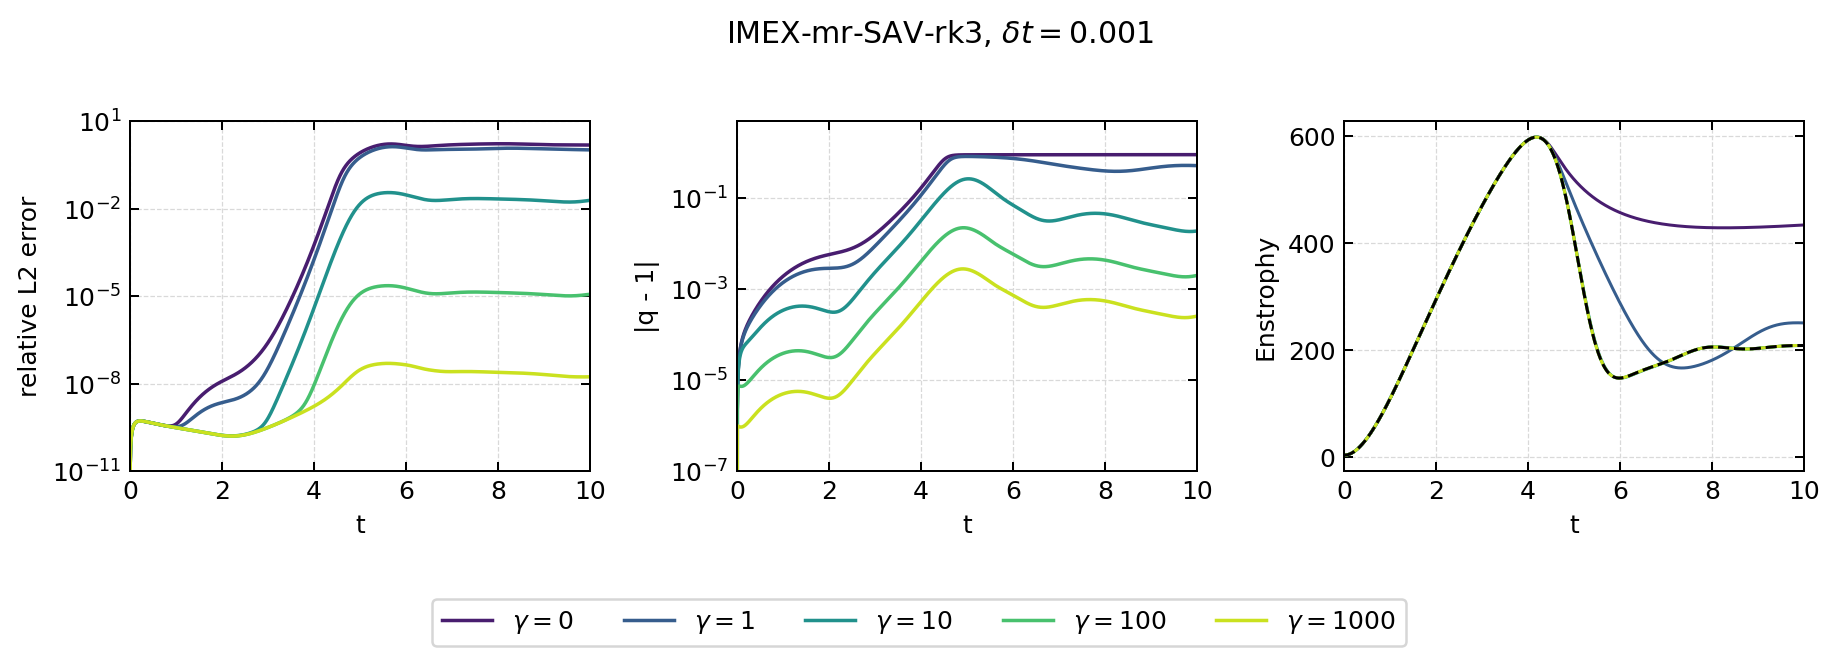

In [36]:
fig = plot_diagnostics(t, gamma_values, gamma_data, ref_enstrophy, attrs)
plt.show()

if SAVE_FIGURES:
    pdf_path, png_path = save_figure(fig, FIG_DIR)
    print(f"saved: {pdf_path}")
    print(f"saved: {png_path}")

In [32]:
rows = build_error_table_rows(t, gamma_values, gamma_data)
display_table(rows)

if SAVE_TABLE:
    saved_table = save_table(rows, TABLE_PATH)
    print(f"saved: {saved_table}")

time,gamma_0_rel_l2,gamma_0_rel_enstrophy,gamma_1_rel_l2,gamma_1_rel_enstrophy,gamma_10_rel_l2,gamma_10_rel_enstrophy,gamma_100_rel_l2,gamma_100_rel_enstrophy,gamma_1000_rel_l2,gamma_1000_rel_enstrophy
2,1.20352339e-08,1.07132830e-09,2.22906450e-09,2.42695832e-10,1.68039475e-10,5.31997703e-12,1.66541699e-10,6.85987416e-12,1.66540449e-10,6.85929685e-12
4,5.64065606e-04,3.01879819e-05,1.80959917e-04,9.36714397e-06,3.94479960e-06,2.02801325e-07,8.88514595e-09,6.98483878e-10,1.66649660e-09,2.97312506e-10
6,1.47420600e+00,2.09148636e+00,1.20228815e+00,9.45051997e-01,2.95208227e-02,2.06051868e-03,1.87682933e-05,1.38806930e-06,4.38311850e-08,4.86875101e-09
8,1.67671914e+00,1.08300645e+00,1.16630042e+00,1.19308028e-01,2.14915045e-02,1.36744239e-03,1.32827780e-05,7.73471164e-07,2.43297135e-08,1.32712518e-09
10,1.51524873e+00,1.08011711e+00,1.03360061e+00,2.02307624e-01,1.92525093e-02,1.93403388e-04,1.15850905e-05,1.09116713e-07,1.70535465e-08,5.63948639e-10
